## Mindshare Case Study – Senior GTM Data Analysis

### Business Challenge: The CMO needs data to answer:
- Is our mindshare growing? Where (region, segment) is it growing, and where is it stalling?
- Which channels build awareness vs. capture existing demand? Are we over-invested in capture?
- Does brand-sourced traffic actually convert? Do warm channels (Direct, Organic, Referral) produce higher-quality MQLs than paid channels?
- What's the right FY27 mindshare investment mix — by channel, region, and segment?

### 1. Setup and data

In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

In [2]:
# Load the Excel file with three tabs
file_path = 'mindshare_dataset.xlsx'

# each tab into a separate df
web = pd.read_excel(file_path, sheet_name='web_visits_weekly')
mql = pd.read_excel(file_path, sheet_name='mql_funnel_weekly')
utm = pd.read_excel(file_path, sheet_name='utm_source_weekly')

### 2. EDA

In [3]:
# Quick EDA
print(web.shape, mql.shape, utm.shape)

(24513, 15) (1612, 10) (323, 8)


In [4]:
# df info- checking for null and incorrect data type
print("Web info:", web.info())
print("MQL info:", mql.info())
print("UTM info:", utm.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24513 entries, 0 to 24512
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   WEEK_START                 24513 non-null  datetime64[ns]
 1   REGION                     24513 non-null  object        
 2   ATTRIBUTION_CHANNEL_GROUP  24513 non-null  object        
 3   VISIT_PATH_CATEGORY        24513 non-null  object        
 4   TOTAL_VISITS               24513 non-null  int64         
 5   UNIQUE_COOKIES             24513 non-null  int64         
 6   MARKETING_SITE_PAGEVIEWS   24513 non-null  int64         
 7   PRICING_PAGE_VISITS        24513 non-null  int64         
 8   DEMO_PAGE_VISITS           24513 non-null  int64         
 9   BLOG_VISITS                24513 non-null  int64         
 10  CTA_CLICKS                 24513 non-null  int64         
 11  DEMO_FORM_SUBMITS          24513 non-null  int64         
 12  CONT

In [5]:
# df info- checking for null and incorrect data type
print("Web describe:", web.describe())
print("MQL describe:", mql.describe())
print("UTM describe:", utm.describe())

Web describe:                           WEEK_START  TOTAL_VISITS  UNIQUE_COOKIES  \
count                          24513  24513.000000    24513.000000   
mean   2025-09-02 17:20:00.587443200    647.402970      576.367846   
min              2024-12-02 00:00:00     10.000000       10.000000   
25%              2025-04-21 00:00:00     28.000000       24.000000   
50%              2025-09-08 00:00:00     77.000000       68.000000   
75%              2026-01-19 00:00:00    242.000000      218.000000   
max              2026-05-25 00:00:00  95337.000000    73680.000000   
std                              NaN   2829.907202     2485.436286   

       MARKETING_SITE_PAGEVIEWS  PRICING_PAGE_VISITS  DEMO_PAGE_VISITS  \
count              24513.000000         24513.000000      24513.000000   
mean                 616.393220            26.476563         23.455554   
min                    0.000000             0.000000          0.000000   
25%                   19.000000             0.000000       

In [6]:
# Data Quality Check
print("Nulls:")
print(" web:", web.isnull().sum().sum(), "| mql:", mql.isnull().sum().sum(), "| utm:", utm.isnull().sum().sum())
print("Duplicate rows:", web.duplicated().sum(), mql.duplicated().sum(), utm.duplicated().sum())

print("\nS1 > total MQLs?", (mql['S1_CONVERSIONS'] > mql['TOTAL_MQLS']).sum())
print("Date range:", web['WEEK_START'].min().date(), "to", web['WEEK_START'].max().date())

print("\nRegions:", sorted(web['REGION'].unique()))
print("Channels:", sorted(web['ATTRIBUTION_CHANNEL_GROUP'].unique()))
print("Segments:", sorted(mql['COMPANY_REPORTING_SEGMENT'].unique()))

Nulls:
 web: 0 | mql: 0 | utm: 0
Duplicate rows: 0 0 0

S1 > total MQLs? 0
Date range: 2024-12-02 to 2026-05-25

Regions: ['APAC', 'EMEA', 'LATAM', 'NAMER', 'Unknown']
Channels: ['Direct', 'Organic', 'Other', 'Paid', 'Powered By']
Segments: ['ENT', 'MM', 'SB', 'Unknown', 'VSB']


In [7]:
web.head()

,WEEK_START,REGION,ATTRIBUTION_CHANNEL_GROUP,VISIT_PATH_CATEGORY,TOTAL_VISITS,UNIQUE_COOKIES,MARKETING_SITE_PAGEVIEWS,PRICING_PAGE_VISITS,DEMO_PAGE_VISITS,BLOG_VISITS,CTA_CLICKS,DEMO_FORM_SUBMITS,CONTACT_SALES_SUBMITS,SIGNUP_VISITS,SUCCESSFUL_SIGNUPS
0,2024-12-02,APAC,Direct,Academy,50,36,8,5,0,0,2,0,0,2,2
1,2024-12-02,APAC,Direct,App Store,121,112,121,0,2,0,5,2,0,4,2
2,2024-12-02,APAC,Direct,Blog & Resources,506,341,505,5,3,480,8,0,0,3,1
3,2024-12-02,APAC,Direct,Campaigns & Reports,15,14,15,0,0,0,1,0,0,0,0
4,2024-12-02,APAC,Direct,Changelog,20,14,20,0,0,0,0,0,0,0,0


In [8]:
mql.head()

,WEEK_START,REGION,COMPANY_REPORTING_SEGMENT,SALES_MOTION,MQL_TYPE,CORE_NONCORE,TOTAL_MQLS,ENGAGED_MQLS,S1_CONVERSIONS,S2_CONVERSIONS
0,2024-12-02,APAC,Unknown,inbound,MQL-Demo,core,20,3,0,0
1,2024-12-02,APAC,VSB,inbound,MQL-Demo,core,14,2,1,1
2,2024-12-02,EMEA,ENT,inbound,MQL-Demo,core,11,4,2,1
3,2024-12-02,EMEA,MM,inbound,MQL-Demo,core,13,2,1,1
4,2024-12-02,EMEA,MM,inbound,MQL-Trial,core,15,1,0,0


In [9]:
utm.head()

,WEEK_START,UTM_SOURCE_CATEGORY,REGION,TOTAL_MQLS,S1_COUNT,S2_COUNT,S1_CONVERSION_RATE_PCT,S2_CONVERSION_RATE_PCT
0,2024-12-02,Direct/Unknown,APAC,70,7,5,10.0,7.1
1,2024-12-02,Direct/Unknown,EMEA,192,15,9,7.8,4.7
2,2024-12-02,Direct/Unknown,LATAM,24,2,2,8.3,8.3
3,2024-12-02,Direct/Unknown,NAMER,255,20,19,7.8,7.5
4,2024-12-09,Direct/Unknown,APAC,69,9,8,13.0,11.6


## Question 1
Is our mindshare growing? Where (region, segment) is it growing and where is it stalling?

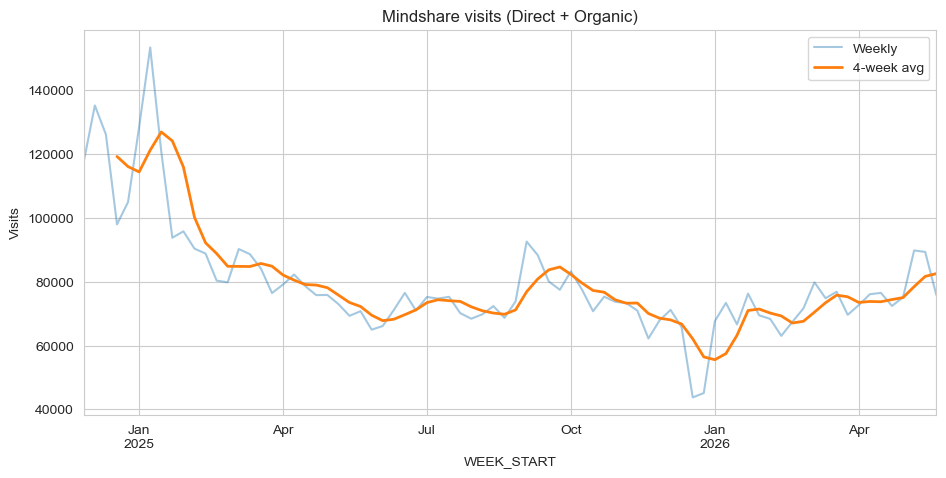

Growth: -36% (last 8 weeks vs first 8 weeks)


<Axes: title={'center': 'Mindshare visits by region'}, xlabel='WEEK_START'>

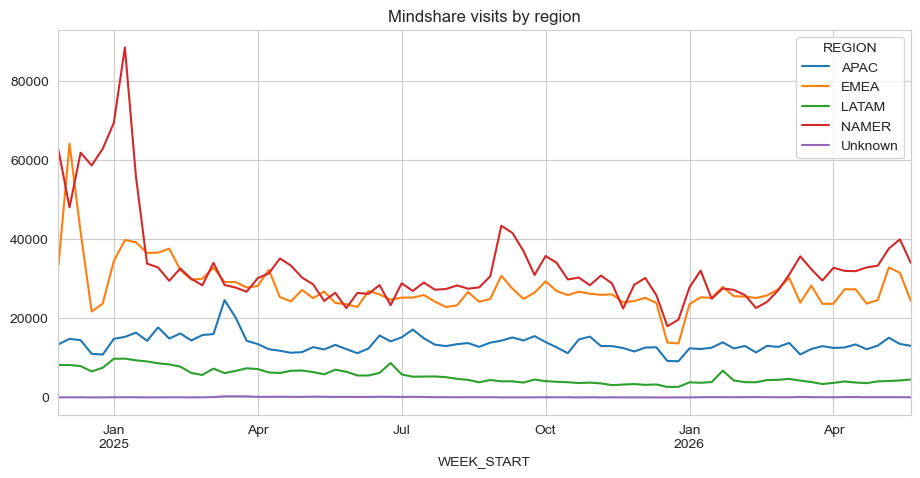

In [10]:
mindshare = web[web['ATTRIBUTION_CHANNEL_GROUP'].isin(['Direct', 'Organic'])]
weekly = mindshare.groupby('WEEK_START')['TOTAL_VISITS'].sum()

weekly.plot(alpha=0.4, label='Weekly')
weekly.rolling(4).mean().plot(lw=2, label='4-week avg')
plt.title('Mindshare visits (Direct + Organic)')
plt.ylabel('Visits'); plt.legend(); plt.show()

growth = (weekly.tail(8).mean() / weekly.head(8).mean() - 1) * 100
print(f"Growth: {growth:+.0f}% (last 8 weeks vs first 8 weeks)")

by_region = mindshare.groupby(['WEEK_START', 'REGION'])['TOTAL_VISITS'].sum().unstack()
by_region.plot(title='Mindshare visits by region')

In [11]:
# jump in visit in early 2025?
weekly = mindshare.groupby('WEEK_START')['TOTAL_VISITS'].sum()
print("Biggest weeks:\n", weekly.sort_values(ascending=False).head(20), "\n")

Biggest weeks:
 WEEK_START
2025-01-13    153339
2024-12-09    135165
2025-01-06    128471
2024-12-16    126074
2025-01-20    120733
2024-12-02    117588
2024-12-30    104948
2024-12-23     97935
2025-02-03     95762
2025-01-27     93752
2025-09-08     92553
2025-02-10     90346
2025-03-10     90221
2026-05-11     89783
2026-05-18     89312
2025-02-17     88802
2025-03-17     88625
2025-09-15     88329
2025-03-24     84118
2025-10-06     83236
Name: TOTAL_VISITS, dtype: int64 



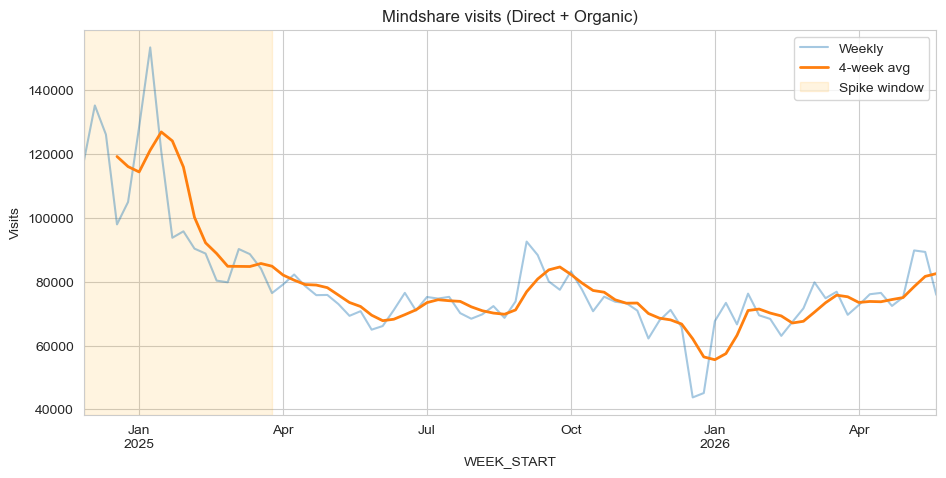

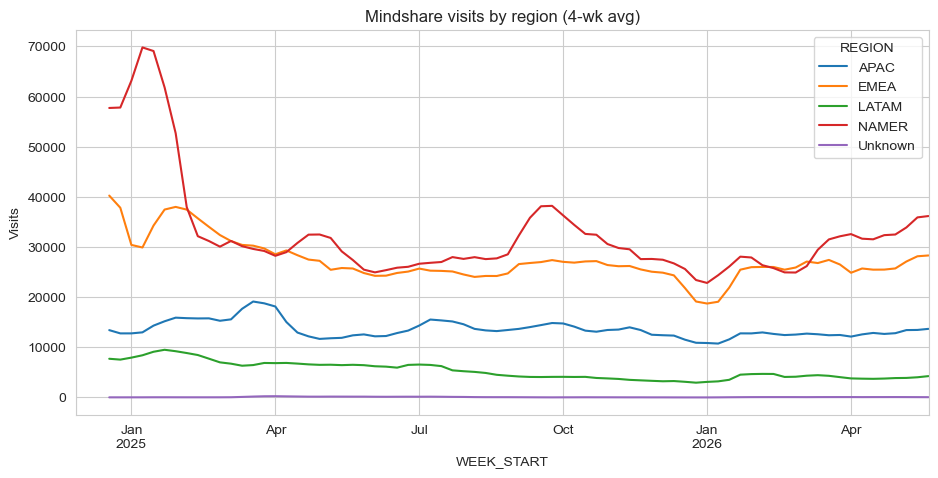

In [12]:
mindshare = web[web['ATTRIBUTION_CHANNEL_GROUP'].isin(['Direct', 'Organic'])].copy()
weekly = mindshare.groupby('WEEK_START')['TOTAL_VISITS'].sum()

ax = weekly.plot(alpha=0.4, label='Weekly')
weekly.rolling(4).mean().plot(ax=ax, lw=2, label='4-week avg')
ax.axvspan(pd.Timestamp('2024-12-01'), pd.Timestamp('2025-03-31'),
           alpha=0.12, color='orange', label='Spike window')
plt.title('Mindshare visits (Direct + Organic)'); plt.ylabel('Visits'); plt.legend(); plt.show()

by_region = mindshare.groupby(['WEEK_START', 'REGION'])['TOTAL_VISITS'].sum().unstack()
by_region.rolling(4).mean().plot(title='Mindshare visits by region (4-wk avg)')
plt.ylabel('Visits'); plt.show()

In [13]:
# Like-for-like YoY: only ISO weeks present in BOTH 2025 and 2026.
# Excluding the spike drops the Dec-Mar surge so 2025 isn't flattered by it.
# Reconciles the -17% (incl) and +2.5% (excl) numbers on the dashboard.
SPIKE_LAST_WEEK = 13   # ~ end of March

def yoy(df, value='TOTAL_VISITS', group=None, exclude_spike=False):
    d = df.copy()
    d['wk'] = d['WEEK_START'].dt.isocalendar().week.astype(int)
    d['yr'] = d['WEEK_START'].dt.year
    common = set(d.loc[d.yr == 2025, 'wk']) & set(d.loc[d.yr == 2026, 'wk'])
    if exclude_spike:
        common = {w for w in common if w > SPIKE_LAST_WEEK}
    d = d[d['wk'].isin(common) & d['yr'].isin([2025, 2026])]
    if group is None:
        t = d.groupby('yr')[value].sum()
        return round(100 * (t[2026] / t[2025] - 1), 1)
    t = d.groupby([group, 'yr'])[value].sum().unstack('yr')
    return (100 * (t[2026] / t[2025] - 1)).round(1)

print("Mindshare YoY  incl spike:", yoy(mindshare), "%")
print("Mindshare YoY  excl spike:", yoy(mindshare, exclude_spike=True), "%")
print("\nChannel YoY (excl spike):\n", yoy(web, group='ATTRIBUTION_CHANNEL_GROUP', exclude_spike=True))
print("\nRegion YoY (excl spike):\n", yoy(mindshare, group='REGION', exclude_spike=True))

Mindshare YoY  incl spike: -17.2 %
Mindshare YoY  excl spike: 2.4 %

Channel YoY (excl spike):
 ATTRIBUTION_CHANNEL_GROUP
Direct        -4.9
Organic       20.8
Other          3.3
Paid          58.7
Powered By   -46.7
dtype: float64

Region YoY (excl spike):
 REGION
APAC        5.1
EMEA       -0.7
LATAM     -40.6
NAMER      14.1
Unknown   -60.4
dtype: float64


## Question 2
Which channels build awareness vs capture demand? 

                            visits  visit_share_%  conv_rate_%
ATTRIBUTION_CHANNEL_GROUP                                     
Direct                     4349257           27.4         1.24
Paid                       4296933           27.1         1.71
Powered By                 4166753           26.3         0.31
Organic                    1877604           11.8         2.53
Other                      1179242            7.4         3.09


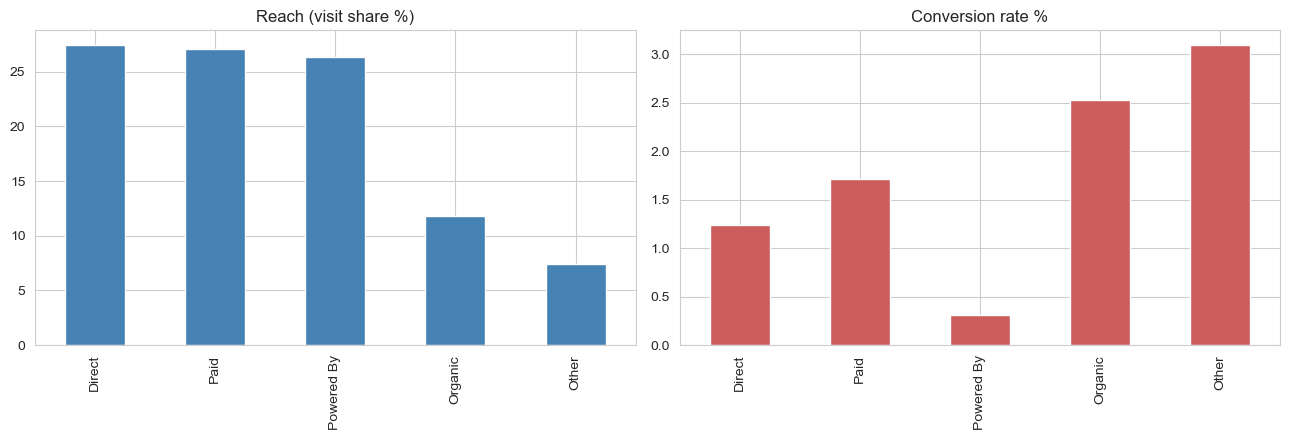

In [14]:
chan = web.groupby('ATTRIBUTION_CHANNEL_GROUP').agg(
    visits=('TOTAL_VISITS', 'sum'),
    demos=('DEMO_FORM_SUBMITS', 'sum'),
    sales=('CONTACT_SALES_SUBMITS', 'sum'),
    signups=('SUCCESSFUL_SIGNUPS', 'sum'))

chan['visit_share_%'] = (100 * chan['visits'] / chan['visits'].sum()).round(1)
chan['conv_rate_%']   = (100 * (chan['demos'] + chan['sales'] + chan['signups']) / chan['visits']).round(2)
chan = chan.sort_values('visits', ascending=False)
print(chan[['visits', 'visit_share_%', 'conv_rate_%']])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
chan['visit_share_%'].plot(kind='bar', ax=ax[0], title='Reach (visit share %)', color='steelblue')
chan['conv_rate_%'].plot(kind='bar', ax=ax[1], title='Conversion rate %', color='indianred')
for a in ax: a.set_xlabel('')
plt.tight_layout(); plt.show()

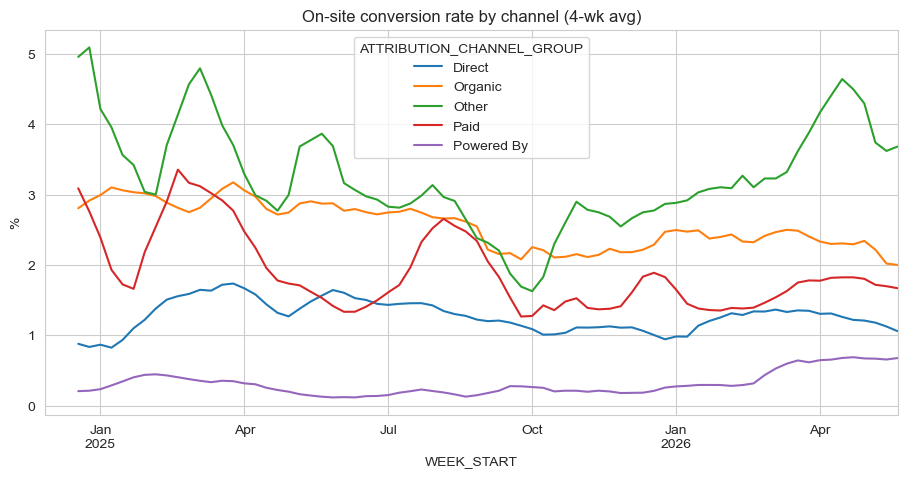

In [15]:
# Conversion-rate trend by channel — Paid drifting down = diminishing returns
g = web.groupby(['WEEK_START', 'ATTRIBUTION_CHANNEL_GROUP']).agg(
    v=('TOTAL_VISITS', 'sum'), c=('DEMO_FORM_SUBMITS', 'sum'),
    s=('CONTACT_SALES_SUBMITS', 'sum'), su=('SUCCESSFUL_SIGNUPS', 'sum')).reset_index()
g['conv'] = 100 * (g['c'] + g['s'] + g['su']) / g['v']
(g.pivot(index='WEEK_START', columns='ATTRIBUTION_CHANNEL_GROUP', values='conv')
   .rolling(4).mean().plot(title='On-site conversion rate by channel (4-wk avg)'))
plt.ylabel('%'); plt.show()

## Question 3
Does brand traffic convert? Brand Quality

In [16]:
motion = mql.groupby('SALES_MOTION').agg(mqls=('TOTAL_MQLS', 'sum'), s1=('S1_CONVERSIONS', 'sum'))
motion['s1_rate'] = (100 * motion['s1'] / motion['mqls']).round(1)
print(motion)

reg = mql.groupby('REGION').agg(mqls=('TOTAL_MQLS', 'sum'), s1=('S1_CONVERSIONS', 'sum'))
reg['s1_rate'] = (100 * reg['s1'] / reg['mqls']).round(1)
print("\n", reg)   # note: LATAM n is tiny -> noise

               mqls    s1  s1_rate
SALES_MOTION                      
inbound       32774  2359      7.2
outbound       1517    60      4.0

          mqls    s1  s1_rate
REGION                      
APAC     1854    66      3.6
EMEA    11149   806      7.2
LATAM      44     5     11.4
NAMER   21244  1542      7.3


                      mqls    s1  s1_rate_%
UTM_SOURCE_CATEGORY                        
Direct/Unknown       45575  3716        8.2
Email                   65     4        6.2
Google                  21     4       19.0
Other                   99    11       11.1


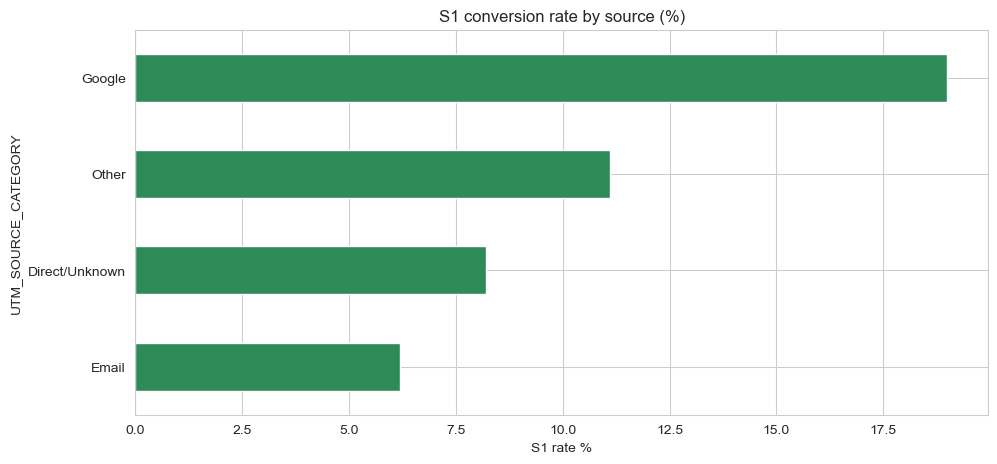


                mqls    s1  s1_rate_%
SALES_MOTION                        
inbound       32774  2359        7.2
outbound       1517    60        4.0

Core MQL ratio %:
 REGION
APAC     64.2
EMEA     90.4
LATAM    72.7
NAMER    81.4
Name: TOTAL_MQLS, dtype: float64


In [17]:
# S1 rate by source — weighted by volume, not a plain mean of weekly rates
src = utm.groupby('UTM_SOURCE_CATEGORY').agg(mqls=('TOTAL_MQLS', 'sum'), s1=('S1_COUNT', 'sum'))
src['s1_rate_%'] = (100 * src['s1'] / src['mqls']).round(1)
print(src)

src['s1_rate_%'].sort_values().plot(kind='barh', title='S1 conversion rate by source (%)', color='seagreen')
plt.xlabel('S1 rate %'); plt.show()

# inbound vs outbound quality
motion = mql.groupby('SALES_MOTION').agg(mqls=('TOTAL_MQLS', 'sum'), s1=('S1_CONVERSIONS', 'sum'))
motion['s1_rate_%'] = (100 * motion['s1'] / motion['mqls']).round(1)
print("\n", motion)

# Core MQL ratio by region (no .apply -> no warning)
core = mql[mql['CORE_NONCORE'] == 'core'].groupby('REGION')['TOTAL_MQLS'].sum()
allm = mql.groupby('REGION')['TOTAL_MQLS'].sum()
print("\nCore MQL ratio %:\n", (100 * core / allm).round(1))

## Queestion 4
Where should FY27 brand dollars go?

In [18]:
# Region share of mindshare visits
region_visits = mindshare.groupby('REGION')['TOTAL_VISITS'].sum()
region_visits_share = 100 * region_visits / region_visits.sum()

# Region share of S1 conversions (pipeline proxy)
region_s1 = mql.groupby('REGION')['S1_CONVERSIONS'].sum()
region_s1_share = 100 * region_s1 / region_s1.sum()

gap = pd.DataFrame({'Visit_Share': region_visits_share, 'S1_Share': region_s1_share})
gap['Gap (Visit - S1)'] = gap['Visit_Share'] - gap['S1_Share']
gap = gap.sort_values('Gap (Visit - S1)')
print(gap)

         Visit_Share   S1_Share  Gap (Visit - S1)
REGION                                           
NAMER      41.569388  63.745349        -22.175961
EMEA       34.577486  33.319554          1.257933
LATAM       6.715342   0.206697          6.508645
APAC       17.035180   2.728400         14.306780
Unknown     0.102604        NaN               NaN


         visit_share_%  s1_share_%  gap_pp
REGION                                    
NAMER             41.6        63.7   -22.1
EMEA              34.6        33.3     1.3
LATAM              6.7         0.2     6.5
APAC              17.0         2.7    14.3
Unknown            0.1         NaN     NaN


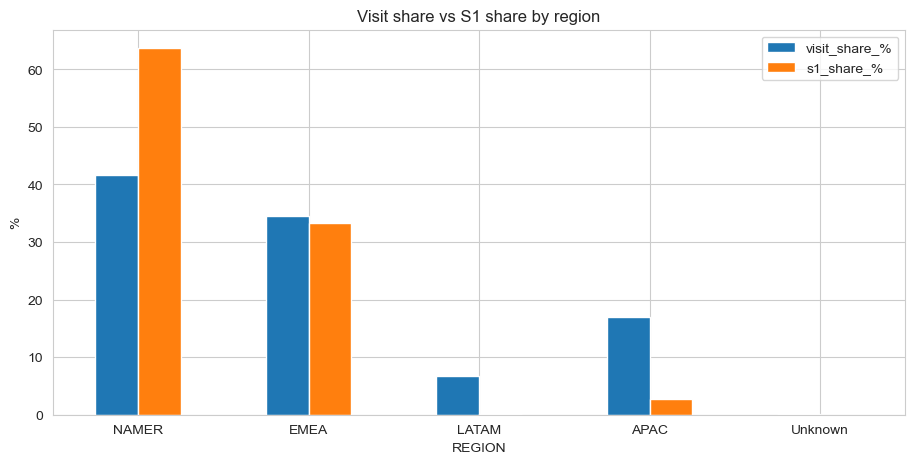

In [19]:
visit_share = 100 * mindshare.groupby('REGION')['TOTAL_VISITS'].sum() / mindshare['TOTAL_VISITS'].sum()
s1_share    = 100 * mql.groupby('REGION')['S1_CONVERSIONS'].sum() / mql['S1_CONVERSIONS'].sum()

gap = pd.DataFrame({'visit_share_%': visit_share.round(1), 's1_share_%': s1_share.round(1)})
gap['gap_pp'] = (gap['visit_share_%'] - gap['s1_share_%']).round(1)
gap = gap.sort_values('gap_pp')
print(gap)

gap[['visit_share_%', 's1_share_%']].plot(kind='bar', title='Visit share vs S1 share by region')
plt.ylabel('%'); plt.xticks(rotation=0); plt.show()